# Biomedical Image Analysis: **Classical Segmentation Baseline**

**Objective**

Before training the neural network, we would come up with a simple and easily interpretable baseline solution.

The pipeline will be as follows:

* **Grayscale image**
* **Otsu thresholding**
* **Morphology**
* **Connected components**
* **Region measurements**

This approach will give us a good reference point for comparison with the U-Net solution while also providing valuable quantitative data for the language model.

### **1. Setup and Data**

This notebook recreates the paths and imports it needs, so it does not depend on variables left in memory by `task1_setup_eda.ipynb`.

In [ ]:
!pip install -q scikit-image pandas matplotlib ollama

from pathlib import Path
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

USE_DRIVE = True  # Set to False to skip Drive entirely and upload manually each session

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path("/content/drive/MyDrive/biomedical_image_project")
else:
    PROJECT_DIR = Path("/content/biomedical_image_project")

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
SRC_DIR = PROJECT_DIR / "src"
SRC_DIR.mkdir(parents=True, exist_ok=True)

if USE_DRIVE and (SRC_DIR / "biomedical_utils.py").exists():
    print("Found biomedical_utils.py on Drive, no upload needed.")
else:
    print("Please upload biomedical_utils.py")
    from google.colab import files
    uploaded = files.upload()
    import shutil
    shutil.move("biomedical_utils.py", str(SRC_DIR / "biomedical_utils.py"))

sys.path.insert(0, str(SRC_DIR))
from biomedical_utils import (
    ensure_dataset,
    load_metadata,
    preprocess_image,
    load_mask,
    otsu_segment,
    dice_score,
    iou_score,
    extract_and_validate_json,
)

DATA_DIR = ensure_dataset()
metadata = load_metadata(DATA_DIR)

print("Dataset:", DATA_DIR)

Mounted at /content/drive
Found biomedical_utils.py on Drive, no upload needed.
Dataset: /content/nuclei_dataset


### **2. Representative example**

We use the same training image selected in the vision-language experiment: the first training image labelled `normal` density.

In [ ]:
representative_row = (
    metadata.loc[
        (metadata["split"] == "train") & (metadata["density"] == "normal")
    ].iloc[0]
)

representative_image = (
    DATA_DIR / "train" / "images" / f"{representative_row['image_id']}.png"
)
representative_mask_path = (
    DATA_DIR / "train" / "masks" / f"{representative_row['image_id']}.png"
)

gray = preprocess_image(representative_image)
ground_truth = load_mask(representative_mask_path).astype(bool)

print("Image:", representative_image)
print("Ground-truth object count:", representative_row["n_objects"])

Image: /content/nuclei_dataset/train/images/train_001.png
Ground-truth object count: 29


### **3. Otsu thresholding**

Otsu thresholding algorithm calculates global intensity threshold between intensity values which split the image into two classes. This algorithm is usually applied as a baseline because it does not require any learning data, but it is a very simple approach and therefore not always optimal. The main drawback of this algorithm is that it finds only one threshold, while in practice, in most cases, for each foreground/background class, there is more than one intensity value.

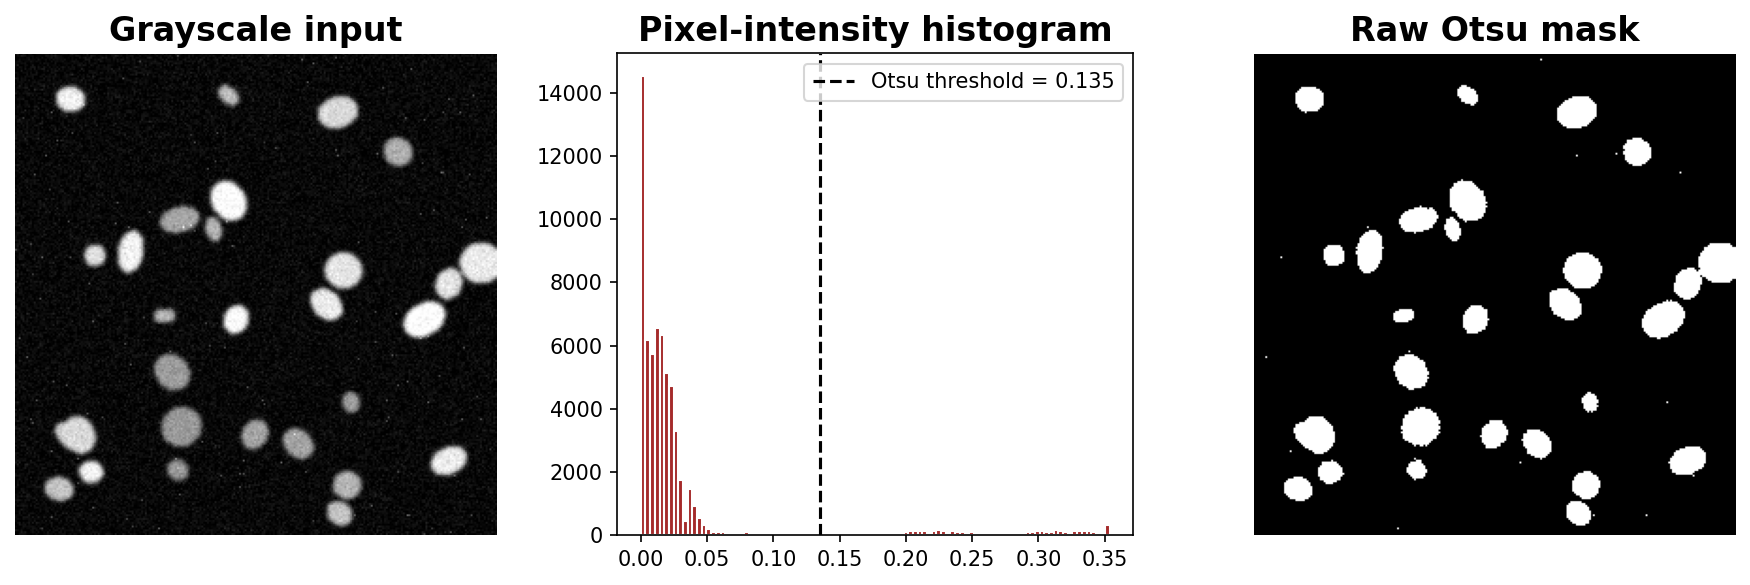

Otsu threshold: 0.1348
Foreground fraction: 8.62%


In [ ]:
from skimage.filters import threshold_otsu

threshold = threshold_otsu(gray)
otsu_mask = gray > threshold

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=150)
axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale input", fontsize=16, fontweight='bold')
axes[0].axis("off")

axes[1].hist(gray.ravel(), bins=100, color="brown", edgecolor="white")
axes[1].axvline(threshold, linestyle="--",
                label=f"Otsu threshold = {threshold:.3f}", color="black")
axes[1].set_title("Pixel-intensity histogram", fontsize=16, fontweight='bold')
axes[1].legend()

axes[2].imshow(otsu_mask, cmap="gray")
axes[2].set_title("Raw Otsu mask", fontsize=16, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.savefig(PROJECT_DIR / "otsu_threshold.png", dpi=720, bbox_inches="tight")
plt.show()

print(f"Otsu threshold: {threshold:.4f}")
print(f"Foreground fraction: {otsu_mask.mean():.2%}")

### **4. Morphological cleanup**

We perform a minor opening operation, eliminate structures smaller than eight pixels, and then perform a minor closing. These relatively conservative morphological operations allow us to remove some obvious noise without adjusting the baseline too drastically.

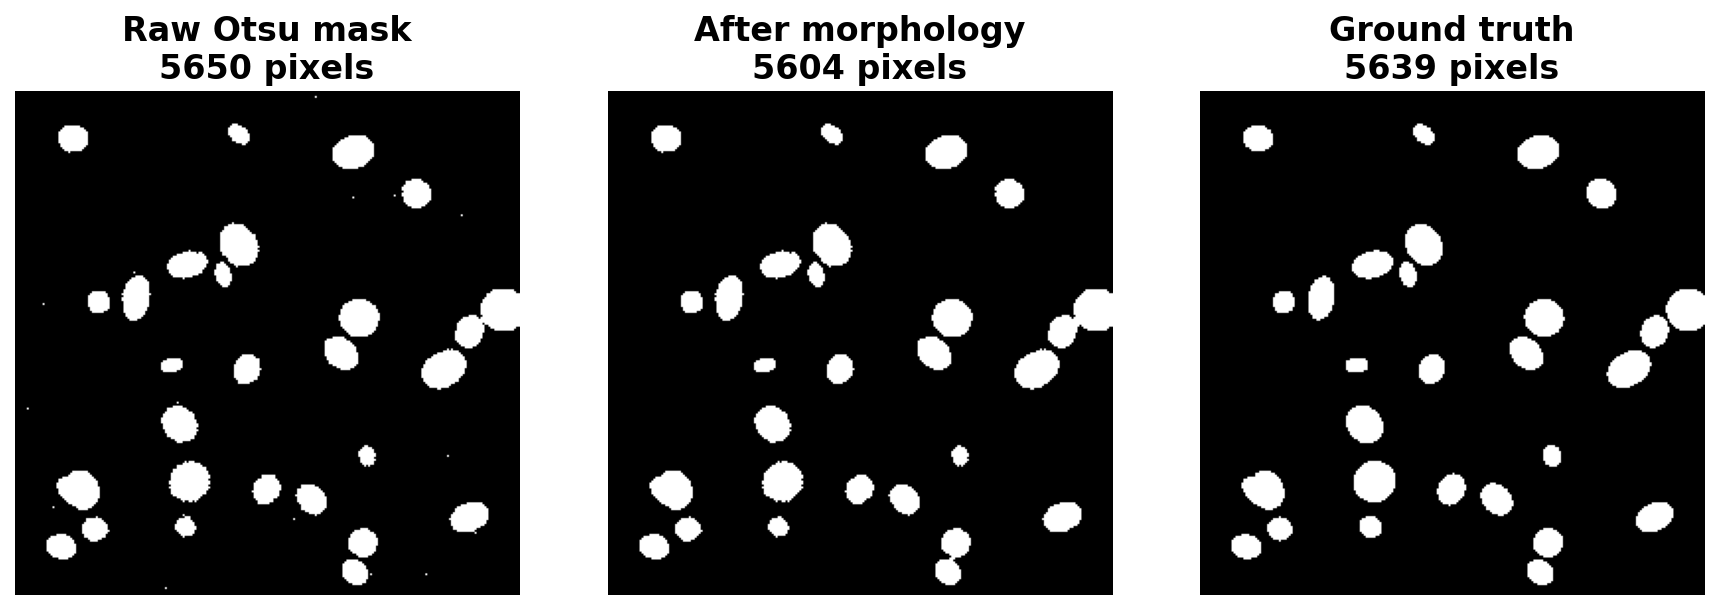

In [ ]:
from skimage.morphology import (
    binary_opening,
    binary_closing,
    remove_small_objects,
    disk,
)

cleaned_mask = binary_opening(otsu_mask, disk(1))
cleaned_mask = remove_small_objects(cleaned_mask, min_size=8)
cleaned_mask = binary_closing(cleaned_mask, disk(1))

fig, axes = plt.subplots(1, 3, figsize=(12, 4),dpi=150)
axes[0].imshow(otsu_mask, cmap="gray")
axes[0].set_title(f"Raw Otsu mask\n{otsu_mask.sum()} pixels",
                  fontsize=16, fontweight='bold')
axes[0].axis("off")

axes[1].imshow(cleaned_mask, cmap="gray")
axes[1].set_title(f"After morphology\n{cleaned_mask.sum()} pixels",
                  fontsize=16, fontweight='bold')
axes[1].axis("off")

axes[2].imshow(ground_truth, cmap="gray")
axes[2].set_title(f"Ground truth\n{ground_truth.sum()} pixels",
                  fontsize=16, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.savefig(PROJECT_DIR / "morphology_cleanup.png", dpi=720, bbox_inches="tight")
plt.show()

### **5. Connected components**

Connected-component labeling assigns a unique label to each connected component (foreground region) in the image. One challenge is that nuclei may appear to touch each other in which case they may be identified as a single connected component, not individual nuclear regions. Connected-component labeling therefore often underestimates the true number of nuclei.

Otsu connected components: 26
Ground-truth object count: 29


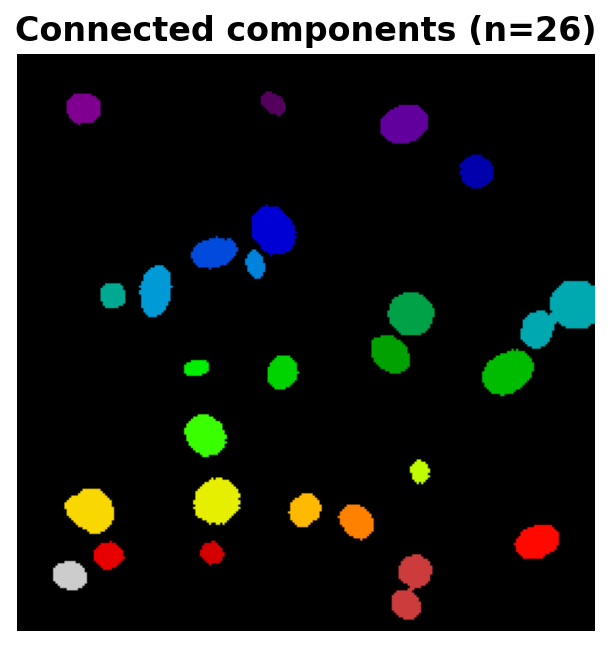

In [ ]:
from skimage.measure import label

labelled = label(cleaned_mask)
n_components = int(labelled.max())

print("Otsu connected components:", n_components)
print("Ground-truth object count:", int(representative_row["n_objects"]))

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.imshow(labelled, cmap="nipy_spectral")
ax.set_title(f"Connected components (n={n_components})",
             fontsize=16, fontweight='bold')
ax.axis("off")
fig.savefig(PROJECT_DIR / "connected_components.png", dpi=720, bbox_inches="tight")
plt.show()

### **6. Region-level measurements**

`regionprops_table` turns the predicted objects into numerical features such as area, eccentricity, solidity, intensity, and shape dimensions.

In [ ]:
from skimage.measure import regionprops_table

props_table = regionprops_table(
    labelled,
    intensity_image=gray,
    properties=[
        "label",
        "area",
        "eccentricity",
        "solidity",
        "mean_intensity",
        "perimeter",
        "major_axis_length",
        "minor_axis_length",
    ],
)
props_df = pd.DataFrame(props_table)

display(props_df.head(10))
print(f"Detected objects represented in table: {len(props_df)}")

props_df.to_csv(PROJECT_DIR / "representative_props_table.csv", index=False)
print("Saved to:", PROJECT_DIR / "representative_props_table.csv")

,label,area,eccentricity,solidity,mean_intensity,perimeter,major_axis_length,minor_axis_length
0,1,84.0,0.744056,0.954545,0.220063,32.384776,12.656506,8.456031
1,2,170.0,0.467372,0.965909,0.291163,45.798990,15.657156,13.841877
2,3,289.0,0.640683,0.986348,0.273657,60.284271,21.883768,16.802470
3,4,176.0,0.239362,0.961749,0.220038,47.455844,15.198490,14.756677
4,5,330.0,0.600761,0.956522,0.311167,67.597980,22.950393,18.347201
5,6,216.0,0.781022,0.931034,0.212702,56.526912,21.012886,13.122619
6,7,82.0,0.769335,0.953488,0.217310,32.384776,12.795933,8.174623
7,8,253.0,0.808356,0.937037,0.291364,61.112698,23.416191,13.784961
8,9,563.0,0.882921,0.844078,0.291794,114.083261,42.177990,19.803447
9,10,106.0,0.192203,0.972477,0.262132,35.313708,11.730812,11.512094


Detected objects represented in table: 26
Saved to: /content/drive/MyDrive/biomedical_image_project/representative_props_table.csv


In [ ]:
if props_df.empty:
    image_summary = {
        "image_id": representative_row["image_id"],
        "n_objects": 0,
        "mean_area": 0.0,
        "std_area": 0.0,
        "mean_eccentricity": 0.0,
        "mean_solidity": 0.0,
        "mean_intensity": 0.0,
        "density_fraction": 0.0,
    }
else:
    image_summary = {
        "image_id": representative_row["image_id"],
        "n_objects": len(props_df),
        "mean_area": props_df["area"].mean(),
        "std_area": props_df["area"].std(),
        "mean_eccentricity": props_df["eccentricity"].mean(),
        "mean_solidity": props_df["solidity"].mean(),
        "mean_intensity": props_df["mean_intensity"].mean(),
        "density_fraction": cleaned_mask.mean(),
    }

for key, value in image_summary.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")
with open(PROJECT_DIR / "representative_image_summary.json", "w") as f:
  json.dump({k: (float(v) if isinstance(v, (np.floating, float)) else v) for
             k, v in image_summary.items()}, f, indent=2)
print("Saved to:", PROJECT_DIR / "representative_image_summary.json")

image_id: train_001
n_objects: 26
mean_area: 215.5385
std_area: 115.2733
mean_eccentricity: 0.5831
mean_solidity: 0.9486
mean_intensity: 0.2511
density_fraction: 0.0855
Saved to: /content/drive/MyDrive/biomedical_image_project/representative_image_summary.json


### **7. Quantitative baseline assessment**

Dice and IoU can be used for computing pixel-wise agreement with the ground truth annotations.

The same model as in the previous experiment is used for the training, validation, and test sets. The results on the test set were used only for the final baseline comparison, and not used for any kind of parameter selection or adjustment.

In [ ]:
results = []

for split in ["train", "val", "test"]:
    split_metadata = metadata[metadata["split"] == split]

    for _, row in split_metadata.iterrows():
        image_path = DATA_DIR / split / "images" / f"{row['image_id']}.png"
        mask_path = DATA_DIR / split / "masks" / f"{row['image_id']}.png"

        _, predicted_mask, n_found = otsu_segment(image_path)
        true_mask = load_mask(mask_path).astype(bool)

        results.append({
            "image_id": row["image_id"],
            "split": split,
            "density": row["density"],
            "n_true": int(row["n_objects"]),
            "n_found": n_found,
            "dice": dice_score(predicted_mask, true_mask),
            "iou": iou_score(predicted_mask, true_mask),
        })

otsu_results = pd.DataFrame(results)
print(f"Evaluated {len(otsu_results)} images.")
display(otsu_results.head())

Evaluated 112 images.


,image_id,split,density,n_true,n_found,dice,iou
0,train_000,train,sparse,10,9,0.972931,0.947288
1,train_001,train,normal,29,26,0.972160,0.945829
2,train_002,train,normal,17,15,0.981104,0.962909
3,train_003,train,normal,36,28,0.980351,0.961459
4,train_004,train,dense,85,43,0.976853,0.954753


Mean segmentation metrics by split:


,dice,iou
split,,
test,0.977601,0.956208
train,0.979669,0.960173
val,0.978271,0.957479


Mean metrics by density regime:


,dice,iou
density,,
clustered,0.978403,0.957735
dense,0.978295,0.957522
normal,0.979285,0.959427
sparse,0.980482,0.961769


Saved split and density summary tables.


<Figure size 1050x600 with 0 Axes>

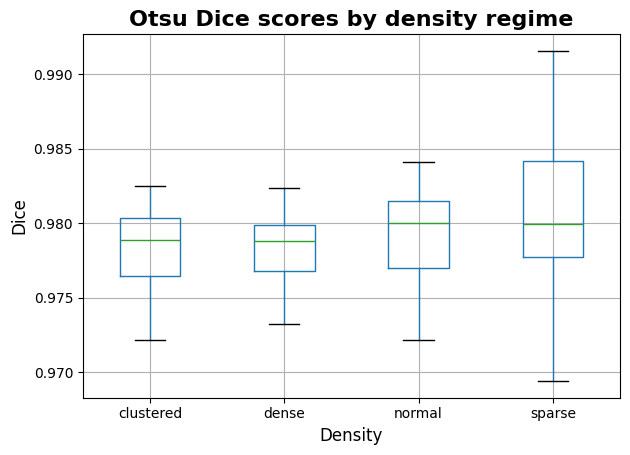

In [ ]:
print("Mean segmentation metrics by split:")
display(
    otsu_results.groupby("split")[["dice", "iou"]].mean().sort_index()
)

print("Mean metrics by density regime:")
display(
    otsu_results.groupby("density")[["dice", "iou"]].mean().sort_index()
)

split_summary = otsu_results.groupby("split")[["dice", "iou"]].mean().sort_index()
density_summary = otsu_results.groupby("density")[["dice", "iou"]].mean().sort_index()

split_summary.to_csv(PROJECT_DIR / "otsu_split_summary.csv")
density_summary.to_csv(PROJECT_DIR / "otsu_density_summary.csv")
print("Saved split and density summary tables.")

plt.figure(figsize=(7, 4), dpi=150)
otsu_results.boxplot(column="dice", by="density", grid=True)
plt.suptitle("")
plt.title("Otsu Dice scores by density regime", fontsize=16, fontweight='bold')
plt.xlabel("Density", fontsize=12)
plt.ylabel("Dice", fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_DIR / "otsu_dice_by_density.png", dpi=720, bbox_inches="tight")
plt.show()

In [ ]:
otsu_results["count_error"] = otsu_results["n_found"] - otsu_results["n_true"]

print("Object-count error by split:")
display(otsu_results.groupby("split")["count_error"].agg(["mean", "std"]))

print("Object-count error by density:")
display(otsu_results.groupby("density")["count_error"].agg(["mean", "std"]))

Object-count error by split:


,mean,std
split,,
test,-13.083333,15.646425
train,-11.750000,13.330749
val,-10.150000,12.179685


Object-count error by density:


,mean,std
density,,
clustered,-27.333333,9.536308
dense,-29.611111,10.901370
normal,-4.803571,3.338043
sparse,-0.300000,0.571241


In [ ]:
otsu_results.to_csv(PROJECT_DIR / "otsu_results.csv", index=False)
print("Saved to:", PROJECT_DIR / "otsu_results.csv")

Saved to: /content/drive/MyDrive/biomedical_image_project/otsu_results.csv


**Interpretation**

The Otsu method showed excellent performance on all three data splits, yielding a mean Dice score of 0.980 on the training set and approximatly 0.978 on both the validation and test sets. It is evident that there was little variance between the results, indicating consistency in performance and no considerable decreases in the quality of the outcomes on unseen data.

The results were also consistent for images with different object densities. The Dice score ranged only between 0.978 and 0.980, suggesting that the algorithm performed almost identically on both clustered and sparse images. Thus, it can be stated that no data density adversely influenced the quality of results.

The results presented above provide a solid baseline for the problem using classical pixel-based image processing techniques. The high scores of Dice and IoU coefficients suggest that the model was able to achieve excellent pixel-level accuracy. However, this does not necessarily mean that the objects were accurately detected or counted.

### **8. Numbers-first language generation**

The project also tests the ability of the model to make decisions based on numerical data rather than images. Here, the model is made aware that it does not have access to the image, so it must not make up any image-related information.

In [ ]:
import subprocess
import time

# Kill any running ollama processes completely
subprocess.run(["pkill", "-9", "-f", "ollama"])
time.sleep(3)

# Confirm nothing is running
subprocess.run(["pgrep", "-f", "ollama"])

!apt-get -qq install -y zstd
!curl -fsSL https://ollama.com/install.sh | OLLAMA_VERSION=0.24.0 sh

server_running = subprocess.run(
    ["pgrep", "-f", "ollama serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
).returncode == 0

if not server_running:
    ollama_process = subprocess.Popen(
        ["ollama", "serve"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    time.sleep(5)

!ollama pull llama3.2-vision
!ollama list

Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

NAME                      ID              SIZE      MODIFIED               
llama3.2-vision:latest    6f2f9757ae97    7.8 GB    Less than a second ago    


In [ ]:
import ollama

numbers_only_prompt = f"""
You are analysing a biomedical image based ONLY on the numerical summary below.
You have NOT been shown the image itself and must not claim to have seen it.

Image analysis summary:
- Number of detected objects: {image_summary["n_objects"]}
- Mean object area: {image_summary["mean_area"]:.1f} pixels
- Standard deviation of object area: {image_summary["std_area"]:.1f} pixels
- Mean eccentricity: {image_summary["mean_eccentricity"]:.3f}
- Mean solidity: {image_summary["mean_solidity"]:.3f}
- Mean object intensity: {image_summary["mean_intensity"]:.3f}
- Foreground fraction: {image_summary["density_fraction"]:.2%}

Write:
1. One short paragraph interpreting these statistics.
2. A JSON object with exactly:
{{
  "n_objects": <integer>,
  "density_class": "sparse | normal | dense | clustered",
  "shape_regularity": "regular | irregular",
  "quality_flag": "statistical anomaly or 'none'"
}}

Do not infer visual details that cannot be supported by these numbers.
""".strip()

numbers_only_response = ollama.chat(
    model="llama3.2-vision",
    messages=[{"role": "user", "content": numbers_only_prompt}],
)

print(numbers_only_response["message"]["content"])

required_fields_t2 = ["n_objects", "density_class", "shape_regularity", "quality_flag"]
parsed_summary, status = extract_and_validate_json(
    numbers_only_response["message"]["content"], required_fields_t2
)
print("\nValidation:", status)

**Interpretation:**

The image appears to contain a relatively large number of small to medium-sized objects, with a moderate degree of shape irregularity. The objects have a high solidity, indicating that they are likely compact and well-defined. The mean object intensity is low, suggesting that the objects may be dark or have low contrast with the background. The foreground fraction is relatively low, indicating that the objects occupy a small proportion of the total image area.

**JSON object:**
{
  "n_objects": 26,
  "density_class": "normal",
  "shape_regularity": "irregular",
  "quality_flag": "none"
}

Validation: JSON parse failed: Expecting value: line 1 column 1 (char 0)


In [ ]:
with open(PROJECT_DIR / "vlm_results.json") as f:
    vlm_output = json.load(f)

print("Task 1 direct-image description:")
print(vlm_output["optimised_response"])

print("\nTask 2 numbers-first description:")
print(numbers_only_response["message"]["content"])

Task 1 direct-image description:
The image shows a microscopic view of cell nuclei, which are visible as bright spots on a dark background. The nuclei appear to be evenly distributed and are of similar size. The background is dark and appears to be a uniform black color.

Here is a valid JSON object describing the image:

{
  "modality": "fluorescence microscopy",
  "tissue_type": "cell nuclei",
  "notable_features": "uniformly distributed, similar size",
  "image_quality": "good, clear, high contrast"
}

Task 2 numbers-first description:
**Interpretation:**

The image appears to contain a relatively large number of small to medium-sized objects, with a moderate degree of shape irregularity. The objects have a high solidity, indicating that they are likely compact and well-defined. The mean object intensity is low, suggesting that the objects may be dark or have low contrast with the background. The foreground fraction is relatively low, indicating that the objects occupy a small propo

In [ ]:
with open(PROJECT_DIR / "numbers_only_response.json", "w") as f:
    json.dump({
        "raw_text": numbers_only_response["message"]["content"],
        "parsed": parsed_summary,
        "validation_status": status,
    }, f, indent=2, default=str)
print("Saved to:", PROJECT_DIR / "numbers_only_response.json")

Saved to: /content/drive/MyDrive/biomedical_image_project/numbers_only_response.json


**Comparison:** direct-image vs. numbers-first description

Both the accounts describe the same fluorescence microscopy image highlighting cell nuclei: bright objects on a dark background. However, there are two essential differences between them.

First, while Task 1 mentions that nuclei are “uniform in size and shape,” the numbers obtained in Task 2 contradict this claim. The standard deviation of nuclei areas is 115, which exceeds the mean area of 216 by over 50%, and the mean eccentricity is 0.583, which is noticeably higher than 0, suggesting that nuclei are far from being circular. Therefore, the second account is more accurate in this regard.

Second, the LLM assigned class ‘normal’ to the image which was also the ground-truth density category. The deterministic Otsu pipeline, on the other hand, detected only 26 objects in the image while the actual number was 29. This was possibly because the merged nuclei were identified as one connected region instead of individual ones. Thus, when it comes to describing quantitative attributes of an image, the second account is more reliable, while the first one contains more subjective information.

### What's next?

In `task3_u-net.ipynb`, we'll replace the hard-coded segmentation with a model-based approach (U-Net), which will allow us to handle more difficult examples. The model will be evaluated on both the validation and test sets.